<style>
/* Persian text styling */
.jp-RenderedHTMLCommon, .rendered_html, .markdown-body, .jp-MarkdownOutput {
    font-family: Vazir, Tahoma, sans-serif !important;
}
</style>

<div dir="rtl" style="text-align: center; padding: 20px; font-family: Vazir, Tahoma, sans-serif;">
  <h1 style="margin: 0; font-size: 30px;">
    تکلیف ۲: تشخیص لهجه‌ها و گویش‌های ایرانی با شبکه ابداعی Parity-Net
  </h1>
  <p style="margin-top: 12px; font-size: 16px; color: #555;">
    Word Embeddings • PyTorch • Custom Neural Architectures • NLP
  </p>
</div>

<div dir="rtl" style="text-align: right; font-family: Tahoma; line-height: 2;">
  <b>نام و نام خانوادگی: مرتضی ملکی‌نژاد شوشتری</b> <br>
  <b>شماره دانشجویی: ۸۱۰۱۰۴۲۵۶</b> 
</div>

<hr style="border-color: #334155;">

<div dir="rtl" style="text-align: right; line-height: 2; padding: 18px; background-color: #0f172a; color: #f8fafc; border-radius: 14px; font-family: Vazir, Tahoma, sans-serif;">

<b>شیوه‌ی تحویل:</b> ارسال فایل کامل همین نوت‌بوک.<br>
<b>نحوه‌ی نمره‌دهی:</b> بخش اصلی نمره بر اساس درستی پیاده‌سازی‌ها است و بخشی هم به خوانایی و کارایی کد اختصاص دارد. هر بخش از 5 بخش ابتدایی این تمرین 20% نمره را دارد. همچنین پاسخ به بخش 6 اُم نیز 10% نمره اضافی در پی خواهد داشت (110% در مجوع). علاوه بر این‌ها نمره‌اضافی تا 10% بیشتر بسته به کیفیت خروجی، ابداع و تحلیل شما ممکن است تعلق بگیرد.<br>
<b>نسخه‌ی پیشنهادی پایتون:</b> Python 3.12 </br>
<b>مجموعه داده‌ی استفاده شده: </b>فایل داده‌ی همراه با نام <code>sentiment_data.csv</code> در همان پوشه‌ی نوت‌بوک. منبع مجموعه دادگان  <a href="https://github.com/SilkRoadAparsin/Sentiment/tree/main/datasets">این مخزن</a> است. توجه فرمائید که از نسخه‌ای استفاده کنید که در کنار نوت‌بوک برای شما قرار داده شده است. </br>
<b>نکات مهم:</b>
استفاده از هوش مصنوعی نه‌تنها مجاز است، بلکه توصیه می‌شود؛ با این حال، باید بر خروجی آن مسلط باشید و آن را به‌طور کامل درک کرده باشید. همچنین استفاده از اینترنت بلامانع است، اما مشورت با هم‌کلاسی‌ها یا استفاده از پاسخ‌های آن‌ها مجاز نیست و این موضوع بررسی خواهد شد. هدف از طراحی این تمرین، سنجش میزان دانش شما از درس و قدرت تحلیل شماست. در پایان، از برخی دانشجویان ارائه‌ی مجازی گرفته خواهد شد تا اطمینان حاصل شود که پاسخ‌های نوشته شده را کامل درک کرده‌اید و توانایی حل مسائل را دارید.

<hr style="border-color: #334155;">

<b>اجرای محلی (Local):</b><br>
برای اجرای این تکلیف روی سیستم شخصی، فقط این موارد را لازم دارید:
<ul style="margin-top: 8px;">
  <li>Python 3.11 یا بالاتر</li>
  <li>Jupyter Notebook یا JupyterLab</li>
  <li>فایل نوت‌بوک</li>
  <li>فایل داده‌ی همراه با نام <code>sentiment_data.csv</code> در همان پوشه‌ی نوت‌بوک</li>
</ul>

سپس نوت‌بوک را باز کنید و مطمئن شوید فایل <code>sentiment_data.csv</code> کنار آن قرار دارد. ممکن است نیاز باشد برخی کتابخانه‌های پایتون را دانلود کنید. اگر امکان اتصال به مخزن اصلی پایتون را نداشتید، طبق راهنمایی موجود در <a href="https://docs.parspack.com/reference/mirror/pypi-pip/">این لینک</a>، از مخزن داخلی استفاده کنید.
</div>

<hr style="border-color: #334155;">

## <div dir="rtl" style="text-align: right; font-family: Vazir, Tahoma, sans-serif;">اطلاعات کلی</div>

<div dir="rtl" style="text-align: right; line-height: 2; padding: 18px; background-color: #0f172a; color: #f8fafc; border-radius: 14px; font-family: Vazir, Tahoma, sans-serif;">
<b>هدف تمرین:</b> آشنایی با پیاده‌سازی شبکه‌های عصبی پیش‌خور (Feed-Forward) و لایه‌های Embedding در PyTorch برای طبقه‌بندی متن.<br>
<b>قوانین اجرا:</b> تمرین طوری طراحی شده است که نیازی به استفاده از GPU نداشته باشد. فایل دیتاست <code>sentiment_data.csv</code> در کنار نوت‌بوک قرار دارد و نیازی به اینترنت برای دانلود دیتا یا مدل‌های از پیش آموزش‌دیده (Pre-trained) ندارید.<br>
<b>معماری ابداعی:</b> در این تمرین، شما از معماری استانداردی استفاده نمی‌کنید. شبکه شما باید کلمات را بر اساس «زوج یا فرد بودن تعداد حروفشان» تفکیک کند که جزئیات آن در بخش‌های بعدی آمده است.

</div>

### <div dir="rtl" style="text-align: right; font-family: Vazir, Tahoma, sans-serif;">بخش ۱: تحلیل و پیش‌پردازش دادگان (Data Analysis & Preprocessing)</div>

<div dir="rtl" style="text-align: right; line-height: 2; font-family: Vazir, Tahoma, sans-serif;">
در اولین گام، باید با دادگانی که در اختیار دارید آشنا شوید. فایل <code>sentiment_data.csv</code> حاوی جملاتی از زبان‌ها، گویش‌ها و لهجه‌های مختلف ایرانی است. 
<br><br>
<b>وظایف شما در این بخش:</b>
<ol>
    <li>فایل دادگان را با استفاده از کتابخانه Pandas بارگذاری کرده و چند سطر نخست آن را برای آشنایی با ساختار ستون‌ها نمایش دهید. توجه فرمائید که هدف پیش‌بینی مادیر ستون <b>accent</b> با استفاده از ستون text یا transliteration یا هر دو است (تصمیم گیری با خودتان!).</li>
    <li><b>تحلیل داده‌ها:</b> تحلیل‌های اکتشافی (EDA) متنوعی را که برای شناخت بهتر مجموعه داده مفید می‌دانید، روی آن انجام دهید. می‌توانید از تکنیک‌های مصورسازی نیز کمک بگیرید. خلاقیت شما در این بخش ارزیابی شده و دارای نمره است.</li>
    <li><b>پیش‌پردازش:</b> اکنون که با داده‌ها آشنا شدید، بررسی کنید که آیا پیش‌پردازش خاصی برای استفاده از آن‌ها نیاز است؟ آیا می‌توان از تمام دادگان به همین شکل استفاده کرد؟ در صورت نیاز، گام‌های پیش‌پردازش (مانند مدیریت مقادیر تهی، حذف یا اصلاح داده‌های نویزی، یکسان‌سازی حروف و پاک‌سازی متن) را پیاده‌سازی و اعمال کنید. (توصیه می‌شود این بخش را هم‌زمان با پیش‌روی در گام‌های بعدی و شناخت نیازهای مدل خود تکمیل کنید.)</li>
    <li>
    تقسیم به دسته‌های آموزش و ارزیابی (و در صورت نیاز به اعتبار سنجی)
    </li>
</ol>
</div>

################## Load and Preview Data ##################
DF Length 800
  language      dialect      accent                                    text  \
0  Caspian  Mazandarani  Tonekaboni                              داره بوشُم   
1  Caspian  Mazandarani  Tonekaboni  خرس اَنه بوخاره، ترکنه (اینه مو ریزنه)   
2  Caspian  Mazandarani  Tonekaboni                             مِره وشنایه   
3  Caspian  Mazandarani  Tonekaboni                            چای نوخارنُم   
4  Caspian  Mazandarani  Tonekaboni     عالی با؛ ماچ تی جان، تی قربان بوشُم   

                              transliteration sentiment_1 sentiment_2  \
0                                 dare bushom     neutral     neutral   
1  khers ane bokhare, terkene (ine mu rizene)    negative    negative   
2                               mere vashnāye    negative     neutral   
3                              chāi nokharnom     neutral    negative   
4      āli bā; māch ti jān, ti ghorbān boshum    positive    positive   

  sentiment_

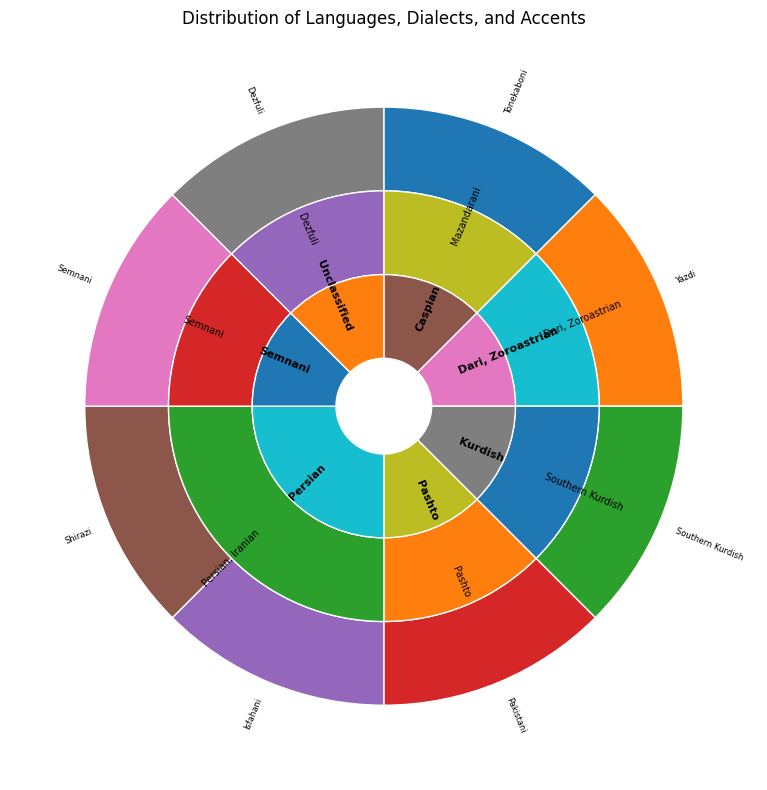

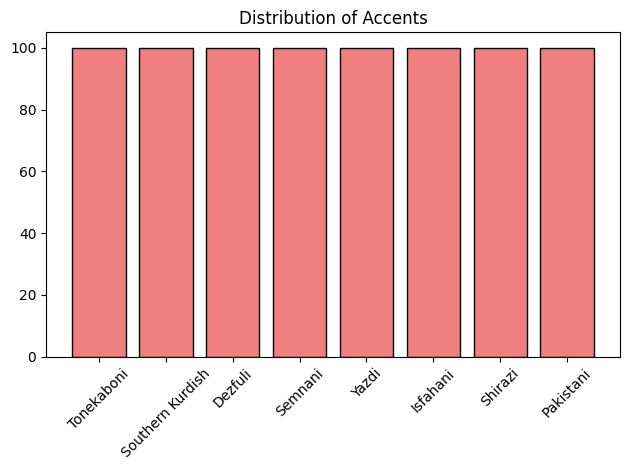

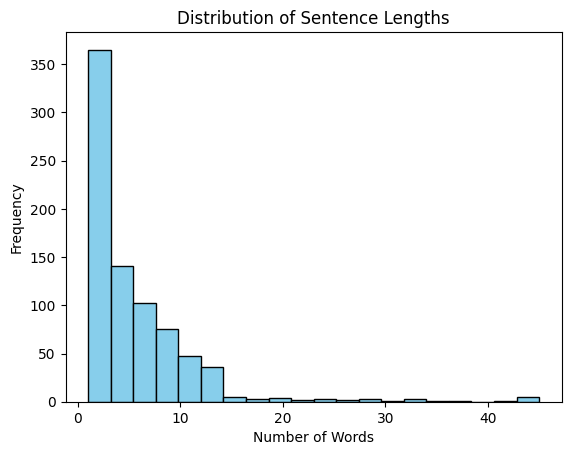


Missing values in each column:
language             0
dialect              0
accent               0
text               199
transliteration    200
sentiment_1         99
sentiment_2         99
sentiment_3         99
dtype: int64

Example rows with nulls (one per column):
            language            dialect      accent       text  \
0  Dari, Zoroastrian  Dari, Zoroastrian       Yazdi        NaN   
1            Caspian        Mazandarani  Tonekaboni  چه ره ری؟   
2            Persian   Persian, Iranian    Isfahani        NaN   
3            Persian   Persian, Iranian    Isfahani        NaN   
4            Persian   Persian, Iranian    Isfahani        NaN   

  transliteration sentiment_1 sentiment_2 sentiment_3  
0       dāroshe      positive    positive     neutral  
1             NaN     neutral     neutral     neutral  
2             NaN         NaN         NaN         NaN  
3             NaN         NaN         NaN         NaN  
4             NaN         NaN         NaN         N

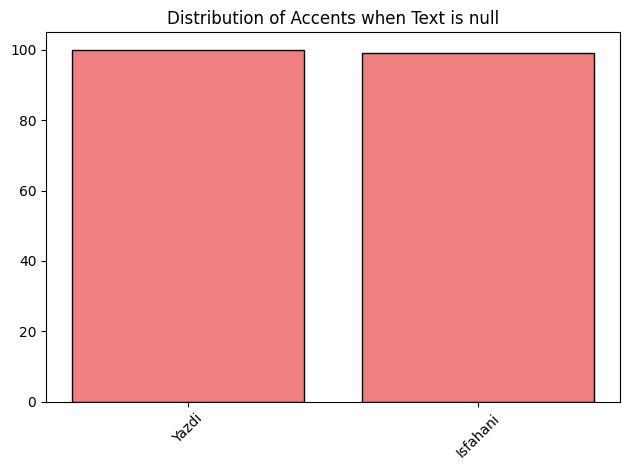

Unique charachters in text column
{'.', 'ٍ', 'ط', 'ت', 'ُ', 'م', 'ٹ', 'ډ', 'پ', 'س', 'ټ', 'ن', 'ٔ', 'ً', 'ە', '٥', 'ۊ', 'ھ', '۹', 'ل', 'ض', 'ئ', 'ِ', 'ذ', 'ْ', '؟', 'ع', '٩', '۳', '،', '۵', 'ّ', 'ظ', 'ش', 'ې', '۰', 'ێ', 'ث', 'ى', '!', 'ښ', 'ک', 'ځ', 'غ', 'ڑ', 'و', '\u200c', '+', '۱', '/', 'آ', 'ج', '3', 'ے', '(', 'ہ', '؛', 'چ', 'خ', '…', 'ك', '5', 'ڼ', 'ا', 'ړ', 'ۍ', 'ق', 'ژ', 'ڵ', ')', 'ف', 'ۆ', 'a', 'څ', 'د', '۔', 'n', 'ي', 'ح', 'ز', 'ه', 'أ', 'ر', 'گ', 'ږ', 'ڈ', '\u061c', 'َ', 'ڕ', '4', '۴', 'ب', 'ص', 'ګ', '٪', 'ی'}
########################## Preprocessing Dataset ##################
########################## Splitting Dataset ##################
Train set length: 539
Test set length: 62
accent
Semnani             94
Dezfuli             93
Shirazi             93
Tonekaboni          91
Pakistani           90
Southern Kurdish    77
Isfahani             1
Name: count, dtype: int64
accent
Southern Kurdish    23
Pakistani           10
Tonekaboni           9
Dezfuli              7
Shirazi 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
# import seaborn as sns 
# import ...

# ==========================================
# Your answer BEGINS HERE
# ==========================================

# ۱. بارگذاری فایل sentiment_data.csv و نمایش سطرهای نخست
print("################## Load and Preview Data ##################")
df = pd.read_csv('sentiment_data.csv')
print("DF Length", len(df))
print(df.head())




# ۲. تحلیل داده‌ها و مصورسازی (EDA)
# (بررسی توزیع کلاس‌ها، رسم نمودارها، بررسی طول جملات، پیدا کردن مقادیر گم‌شده یا نویزی و ...)
print("################## Exploratory Data Analysis ##################")

fig, ax = plt.subplots(figsize=(8, 8))

language_labels = []
language_sizes = []
dialect_labels = []
dialect_sizes = []
accent_labels = []
accent_sizes = []

for language, lang_group in df.groupby('language', sort=True):
    language_labels.append(language)
    language_sizes.append(len(lang_group))
    for dialect, dia_group in lang_group.groupby('dialect', sort=True):
        dialect_labels.append(dialect)
        dialect_sizes.append(len(dia_group))
        for accent, acc_group in dia_group.groupby('accent', sort=True):
            accent_labels.append(accent)
            accent_sizes.append(len(acc_group))

ax.pie(
    accent_sizes,
    radius=1.0,
    labels=accent_labels,
    labeldistance=1.05,
    textprops=dict(fontsize=6),
    wedgeprops=dict(width=0.28, edgecolor="white"),
    startangle=90,
    counterclock=False,
    rotatelabels=True,
 )

ax.pie(
    dialect_sizes,
    radius=0.72,
    labels=dialect_labels,
    labeldistance=0.8,
    textprops=dict(fontsize=7),
    wedgeprops=dict(width=0.28, edgecolor="white"),
    startangle=90,
    counterclock=False,
    rotatelabels=True,
 )

ax.pie(
    language_sizes,
    radius=0.44,
    labels=language_labels,
    labeldistance=0.6,
    textprops=dict(fontsize=8, fontweight="bold"),
    wedgeprops=dict(width=0.28, edgecolor="white"),
    startangle=90,
    counterclock=False,
    rotatelabels=True,
 )

ax.set(aspect="equal", title="Distribution of Languages, Dialects, and Accents")
plt.tight_layout()
plt.show()

# since we want to predict accent from text, lets see accent distribution
plt.bar(df['accent'].value_counts().index, df['accent'].value_counts().values, color='lightcoral', edgecolor='black'  )
plt.title("Distribution of Accents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.hist(df['text'].apply(lambda x: len(str(x).split())), bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Sentence Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

print("\nMissing values in each column:")
print(df.isnull().sum())

null_columns = df.columns[df.isnull().any()].tolist()
null_examples = []
for col in null_columns:
    sample = df[df[col].isnull()].head(1)
    if not sample.empty:
        null_examples.append(sample)

if null_examples:
    null_examples_df = pd.concat(null_examples, ignore_index=True)
    print("\nExample rows with nulls (one per column):")
    print(null_examples_df)
else:
    print("\nNo null values found in any column.")

plt.bar(
    df[df['text'].isnull()]['accent'].value_counts().index, 
    df[df['text'].isnull()]['accent'].value_counts().values, 
    color='lightcoral', 
    edgecolor='black'  
)
plt.title("Distribution of Accents when Text is null")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Unique charachters in text column")
words = list(df['text'].apply(lambda x: str(x).split()).explode().unique())
chars = set([char for word in words for char in word])
print(chars)


# ۳. پیش‌پردازش دادگان
# (اصلاح برچسب‌های نویزی در صورت وجود، پاک‌سازی متن‌ها، حذف ردیف‌های نامعتبر و ...)
print("########################## Preprocessing Dataset ##################")
df.dropna(subset=['text'], inplace=True)
df.dropna(subset=['accent'], inplace=True)





# ۴. تقسیم دادگان به دسته‌های آموزش، ارزیابی و در صورت نیاز اعتبار سنجی
# df length is now 600 
# since we don't have that much data, we do a 90-10 split for train and test, and use cross-validation on the training set instead of having a separate validation set.
print("########################## Splitting Dataset ##################")
train_indexes = np.random.rand(len(df)) < 0.9
train_df = df[train_indexes]
test_df = df[~train_indexes]
print("Train set length:", len(train_df))
print("Test set length:", len(test_df))
print(train_df['accent'].value_counts())
print(test_df['accent'].value_counts())
# ==========================================
# Your answer ENDS HERE
# ==========================================

### <div dir="rtl" style="text-align: right; font-family: Vazir, Tahoma, sans-serif;">بخش ۲: توکنایز کردن متون و ساخت واژه‌نامه (Tokenization & Vocabulary)</div>

<div dir="rtl" style="text-align: right; line-height: 2; font-family: Vazir, Tahoma, sans-serif;">
مدل‌های یادگیری ماشین و شبکه‌های عصبی نمی‌توانند متون خام را به‌طور مستقیم پردازش کنند. بنابراین، باید جملات را به واحدهای کوچکتری به نام «توکن» (Token) بشکنیم و سپس هر توکن را به یک شناسه عددی (Index) منحصربه‌فرد نگاشت کنیم.
<br><br>
<b>وظایف شما در این بخش:</b>
<ol>
    <li><b>ساخت واژه‌نامه (Vocabulary):</b> یک دیکشنری (Dictionary) بسازید که هر توکنِ یکتا در دادگان را به یک عدد صحیح اختصاص دهد. 
        <br><i>نکته بسیار مهم:</i> حتماً دو توکن ویژه <code>[PAD]</code> (برای هم‌طول‌سازی جملات، معمولاً با شناسه ۰) و <code>[UNK]</code> (برای کلمات خارج از واژه‌نامه، معمولاً با شناسه ۱) را در ابتدای واژه‌نامه خود تعریف کنید.</li>
    <li><b>توکنایز کردن:</b> تابعی بنویسید که متن پیش‌پردازش‌شده را به لیستی از توکن‌ها تبدیل کند. برای سادگی می‌توانید از جداکننده فاصله (Whitespace) استفاده کنید (مثلاً متد <code>split()</code>). با این حال، استفاده از توکنایزرهای پیشرفته‌تر (مانند توکنایزر <code>Hazm</code>، <code>ParsBERT</code> یا توکنایزرهای مبتنی بر زیرکلمه) می‌تواند دقت مدل شما را، به‌ویژه در برخورد با گویش‌ها و لهجه‌های مختلف این دیتاست، بهبود بخشد و امتیاز تشویقی دارد.</li>
    <li><b>تبدیل متن به شناسه (Encoding):</b> با استفاده از واژه‌نامه، تمام جملات دیتاست را به دنباله‌ای از اعداد تبدیل کنید. کلماتی که در واژه‌نامه وجود ندارند باید به شناسه <code>[UNK]</code> تبدیل شوند.</li>
</ol>
</div>

In [2]:
# ==========================================
# Your answer BEGINS HERE
# ==========================================

# تعریف توکن‌های ویژه
PAD_TOKEN = "[PAD]"
UNK_TOKEN = "[UNK]"

# ۱. ساخت واژه‌نامه
# دیکشنری‌های نگاشت توکن به شناسه و برعکس
word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
idx2word = {0: PAD_TOKEN, 1: UNK_TOKEN}
# توکن‌های جدید را به دو دیکشنری فوق اضافه کنید.
k = 1000
tokens = set(chars)
def bpe_tokenize_word(word):
    if not word:
        return []
    ind = 0
    candidate = ""
    ans = []
    while ind < len(word):
        if ind < len(word) and candidate + word[ind] in tokens:
            candidate += word[ind]
            ind += 1
            continue
        if candidate not in tokens:
            candidate = UNK_TOKEN
        ans.append(candidate)
        candidate = word[ind]
        ind += 1
    if candidate:
        if candidate not in tokens:
            candidate = UNK_TOKEN
        ans.append(candidate)
    return ans

def bpe_tokenize(text):
    tokens = []
    for word in str(text).split():
        tokens.extend(bpe_tokenize_word(word))
    return tokens

def add_novel_token():
    tokenized_texts = train_df['text'].apply(bpe_tokenize)
    candidates = Counter()
    token_usage = Counter()
    for tokenized_text in tokenized_texts:
        if tokenized_text:
            token_usage[tokenized_text[0]] += 1
        for i in range(len(tokenized_text) - 1):
            candiate = tokenized_text[i] + tokenized_text[i+1]
            candidates[candiate] += 1
            token_usage[tokenized_text[i + 1]] += 1

    for token in list(tokens):
        if token_usage[token] == 0 and token not in [PAD_TOKEN, UNK_TOKEN] and len(token ) > 1:
            tokens.remove(token)
    if not candidates:
        return
    most_common_candidate = candidates.most_common(1)[0]
    tokens.add(most_common_candidate[0])
for i in range(k):
    add_novel_token()
for token in tokens:
    if token in word2idx:
        continue
    word2idx[token] = len(word2idx)
    idx2word[len(idx2word)] = token
print(word2idx)



# ۲. تابع توکنایزر
def tokenize(text):
    """
    متن ورودی را دریافت کرده و لیستی از توکن‌ها را برمی‌گرداند.
    """
    if not isinstance(text, str):
        return []
    
    # کد توکنایز کردن خود را اینجا بنویسید (استفاده از split یا کتابخانه‌ها و روش‌های دیگر)
    return bpe_tokenize(text)
    



# ۳. تابع تبدیل متن توکنایزشده به شناسه‌های عددی
def encode_text(tokens):
    """
    لیستی از توکن‌ها را گرفته و لیستی از اعداد برمی‌گرداند.
    """
    # کلمات ناموجود در واژه‌نامه باید به شناسه [UNK] تبدیل شوند
    return [word2idx.get(token, word2idx[UNK_TOKEN]) for token in tokens]

# اعمال توابع فوق روی دیتافریم و ذخیره نتیجه در یک ستون جدید (مثلاً 'encoded_text')
df['encoded_text'] = df['text'].apply(lambda x: encode_text(tokenize(x)))
train_df['encoded_text'] = train_df['text'].apply(lambda x: encode_text(tokenize(x)))
test_df['encoded_text'] = test_df['text'].apply(lambda x: encode_text(tokenize(x)))


# ==========================================
# Your answer ENDS HERE
# ==========================================

# کدهای ارزیابی اولیه
print(f"Total Vocabulary Size: {len(word2idx)}")

# بررسی صحت خروجی روی یکی از داده‌ها
if df is not None and 'encoded_text' in df.columns:
    sample_idx = 0
    print("\n--- Sample Encoding ---")
    print("Original Text: ", df['text'].iloc[sample_idx])
    print("Tokenized:     ", tokenize(df['text'].iloc[sample_idx]))
    print("Encoded IDs:   ", df['encoded_text'].iloc[sample_idx])
else:
    print("Encoding step is not completed yet.")

{'[PAD]': 0, '[UNK]': 1, 'ِی': 2, 'سی': 3, 'ط': 4, 'دَ': 5, 'کو': 6, 'نو': 7, 'ت': 8, 'ته': 9, 'ٹ': 10, 'س': 11, 'ټ': 12, 'ن': 13, 'چی': 14, 'ً': 15, 'ە': 16, '٥': 17, 'ھ': 18, '۹': 19, 'ض': 20, 'کی': 21, 'ِ': 22, 'ذ': 23, 'که': 24, 'ْ': 25, 'ری': 26, '؟': 27, 'ع': 28, 'ست': 29, '۳': 30, '۵': 31, 'ظ': 32, 'ِن': 33, 'لا': 34, 'ې': 35, 'ێ': 36, 'ث': 37, 'عا': 38, 'به': 39, 'ان': 40, 'َر': 41, 'ُو': 42, 'ڑ': 43, 'و': 44, 'با': 45, '/': 46, '3': 47, 'می\u200c': 48, 'ے': 49, '؛': 50, 'چ': 51, 'خ': 52, '…': 53, 'ك': 54, '5': 55, 'دا': 56, 'ه\u200c': 57, 'ا': 58, 'ۍ': 59, 'ق': 60, 'ژ': 61, 'لو': 62, 'ڵ': 63, 'خو': 64, ')': 65, 'ف': 66, 'څ': 67, '۔': 68, 'n': 69, 'ي': 70, 'نا': 71, 'بٍ': 72, 'سا': 73, 'ره': 74, 'أ': 75, 'گ': 76, 'ږ': 77, 'َ': 78, 'نَ': 79, 'رو': 80, 'ب': 81, 'وی': 82, 'ص': 83, 'ٍر': 84, 'ګ': 85, 'تی': 86, 'مو': 87, 'نه': 88, '٪': 89, 'از': 90, '.': 91, 'ٍ': 92, 'ُ': 93, 'م': 94, 'ډ': 95, 'پ': 96, 'لی': 97, 'ٔ': 98, 'ۊ': 99, 'نگ': 100, 'ل': 101, 'ئ': 102, 'َه': 103, 'هم': 104, 

### <div dir="rtl" style="text-align: right; font-family: Vazir, Tahoma, sans-serif;">بخش ۳: ساخت  Dataset و DataLoader برای پای‌تورچ</div>

<div dir="rtl" style="text-align: right; line-height: 2; font-family: Vazir, Tahoma, sans-serif;">
اکنون هدف ما پیش‌بینی <b>لهجه (Accent)</b> گوینده از روی متن است. شبکه‌های عصبی در PyTorch برای دریافت داده‌ها نیازمند ساختارهایی به نام <b>تنسور (Tensor)</b> و ماتریس‌هایی با ابعاد یکسان هستند. 
<br><br>
از آنجایی که طول جملات ما با هم تفاوت دارد، باید پیش از ارسال آن‌ها به مدل، فرآیند <b>هم‌طول‌سازی (Padding & Truncation)</b> را انجام دهیم. به این صورت که یک طول بیشینه (مثلاً <code>max_len = 30</code>) در نظر می‌گیریم؛ جملات طولانی‌تر را قطع می‌کنیم و به انتهای جملات کوتاه‌تر توکن <code>[PAD]</code> اضافه می‌کنیم تا همگی هم‌اندازه شوند.
<br><br>
<b>وظایف شما در این بخش:</b>
<ol>
    <li>کلاس سفارشی <code>AccentDataset</code> را تکمیل کنید. در متد <code>__getitem__</code>، عملیات Truncation و Padding را روی لیست توکن‌ها اعمال کرده و هر دو خروجی (متن و برچسب لهجه) را به <code>torch.tensor</code> با نوع داده‌ی <code>long</code> تبدیل کنید.</li>
    <li>با استفاده از داده‌های آموزش و آزمون (که در مراحل پیشین جدا کرده‌اید)، دو شیء از این کلاس بسازید.</li>
    <li>اشیای <code>train_loader</code> و <code>test_loader</code> را بسازید (مقدار <code>batch_size</code> را ترجیحاً 8 در نظر بگیرید). اطمینان حاصل کنید که دیتالودر مربوط به آموزش، داده‌ها را بُر می‌زند (<code>shuffle=True</code>).</li>
</ol>
</div>

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader

# ==========================================
# Your answer BEGINS HERE
# ==========================================

# ۱. تکمیل کلاس Dataset برای تشخیص لهجه
class AccentDataset(Dataset):
    def __init__(self, encoded_texts, accent_labels, max_len=30):
        """
        encoded_texts: لیستی از لیست‌های اعداد (شناسه توکن‌ها)
        accent_labels: لیستی از برچسب‌های عددی لهجه‌ها
        max_len: طول استانداردی که همه جملات باید به آن برسند
        """
        self.texts = encoded_texts
        self.labels = accent_labels
        self.max_len = max_len

    def __len__(self):
        # بازگرداندن تعداد کل نمونه‌ها
        return len(self.texts)

    def __getitem__(self, idx):
        text_seq = self.texts[idx]
        label = self.labels[idx]

        # پیاده‌سازی Truncation (قطع کردن دنباله‌های طولانی‌تر از max_len)
        if len(text_seq) > self.max_len:
            text_seq = text_seq[:self.max_len]
        
        # پیاده‌سازی Padding (اضافه کردن شناسه توکن [PAD] به انتهای دنباله‌های کوتاه‌تر)
        # راهنمایی: شناسه [PAD] در بخش قبل مقداردهی شده است (معمولاً عدد صفر است).
        if len(text_seq) < self.max_len:
            text_seq = text_seq + [word2idx[PAD_TOKEN]] * (self.max_len - len(text_seq))

        
        # تبدیل داده‌ها به تنسورهای پای‌تورچ (حتماً از dtype=torch.long استفاده کنید)
        # text_tensor = ...
        # label_tensor = ...
        text_tensor = torch.tensor(text_seq, dtype=torch.long)
        label_tensor = torch.tensor(label, dtype=torch.long)
        
        return text_tensor, label_tensor

# ۲. ساخت اشیاء Dataset (با فرض اینکه X_train, X_test, y_train, y_test آماده هستند)
accent2idx = {label: i for i, label in enumerate(sorted(df['accent'].unique()))}
idx2accent = {i: label for label, i in accent2idx.items()}

train_dataset = AccentDataset(
    encoded_texts=train_df['encoded_text'].tolist(),
    accent_labels=train_df['accent'].map(accent2idx).tolist(),
    max_len=30
)
test_dataset = AccentDataset(
    encoded_texts=test_df['encoded_text'].tolist(),
    accent_labels=test_df['accent'].map(accent2idx).tolist(),
    max_len=30
)

# ۳. ساخت اشیاء DataLoader
BATCH_SIZE = 8
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# Your answer ENDS HERE
# ==========================================

# کدهای ارزیابی اولیه برای اطمینان از صحت ابعاد
if train_loader is not None:
    sample_batch_texts, sample_batch_labels = next(iter(train_loader))
    print(f"Batch Texts Shape: {sample_batch_texts.shape}")
    print(f"Batch Labels Shape: {sample_batch_labels.shape}")
    print("\nSample Label Tensor:", sample_batch_labels[:5])
else:
    print("DataLoaders are not initialized yet.")

Batch Texts Shape: torch.Size([8, 30])
Batch Labels Shape: torch.Size([8])

Sample Label Tensor: tensor([3, 4, 5, 3, 3])


### <div dir="rtl" style="text-align: right; font-family: Vazir, Tahoma, sans-serif;">بخش ۴: معماری شبکه عصبی ابداعی (Parity-Net)</div>

<div dir="rtl" style="text-align: right; line-height: 2; font-family: Vazir, Tahoma, sans-serif;">
در این مرحله باید شبکه‌ی عصبی خود را طراحی کنید. ما از یک معماری به نام <b>Parity-Net</b> استفاده می‌کنیم. در این شبکه، مدل برای کلماتی که تعداد حروفشان زوج است از یک لایه Embedding، و برای کلماتی که تعداد حروفشان فرد است از یک لایه Embedding دیگر استفاده می‌کند.
<br><br>
<b>قوانین ساخت این معماری (بسیار ساده):</b>
<ol>
    <li><b>تعریف لایه‌ها:</b> در متد <code>__init__</code>، دو لایه Embedding مجزا بسازید:
        <ul>
            <li><code>emb_even</code>: با سایز ورودی برابر با کل واژه‌نامه و بُعد خروجی <b>64</b>.</li>
            <li><code>emb_odd</code>: با سایز ورودی برابر با کل واژه‌نامه و بُعد خروجی <b>64</b>.</li>
        </ul>
    </li>
    <li><b>جدا کردن ایندکس‌ها:</b> شما باید در متد سازنده، لیست ایندکس‌هایی که مربوط به کلمات زوج هستند و لیست ایندکس‌هایی که مربوط به کلمات فرد هستند را پیدا کنید (با یک حلقه <code>for</code> ساده روی <code>word2idx</code>).</li>
    <li><b>فریز کردن متقاطع (Cross-Freezing):</b> برای اینکه لایه زوج فقط کلمات زوج را یاد بگیرد، باید وزن‌های (Weights) مربوط به کلمات فرد را در <code>emb_even</code> <b>صفر و فریز</b> کنید. بالعکس، در <code>emb_odd</code>، وزن‌های مربوط به کلمات زوج را صفر و فریز کنید. (راهنمایی: می‌توانید مستقیماً به <code>emb.weight.data</code> دسترسی پیدا کنید).</li>
    <li><b>جریان داده (Forward Pass):</b> 
        <ul>
            <li>ورودی <code>input_ids</code> را به هر دو امبدینگ بدهید. (چون وزن‌های نامربوط صفر شده‌اند، خروجی <code>emb_even</code> برای کلمات فرد تماماً صفر خواهد بود).</li>
            <li>روی بُعد توکن‌ها (طول جمله) میانگین (mean) بگیرید.</li>
            <li>دو بردار به دست آمده را با هم جمع (Sum) کنید.</li>
            <li>بردار نهایی را از یک لایه خطی (Linear) عبور دهید تا خروجی کلاس‌ها تولید شود.</li>
        </ul>
    </li>
</ol>
</div>

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ==========================================
# Your answer BEGINS HERE
# ==========================================

class ParityNet(nn.Module):
    def __init__(self, vocab_size, word2idx, num_classes):
        super(ParityNet, self).__init__()
        
        # ۱. تعریف امبدینگ‌ها
        self.emb_even = nn.Embedding(vocab_size, 64, padding_idx=0)
        self.emb_odd = nn.Embedding(vocab_size, 64, padding_idx=0)
        
        # ۲. پیدا کردن ایندکس‌های زوج و فرد
        even_indices = [idx for word, idx in word2idx.items() if len(word) % 2 == 0]
        odd_indices = [idx for word, idx in word2idx.items() if len(word) % 2 == 1]
        
        # حلقه روی word2idx برای پر کردن لیست‌های بالا
        # ...
        
        # ۳. فریز کردن متقاطع (صفر کردن وزن‌های نامربوط در هر لایه)
        # دقت: برای جلوگیری از آپدیت شدن این وزن‌های صفر، requires_grad آن‌ها را false نمی‌کنیم، 
        # بلکه کلاً دیتای آن‌ها را صفر نگه می‌داریم (این یک روش ساده برای درک مفهوم است).
        
        with torch.no_grad():
            if len(odd_indices) > 0:
                self.emb_even.weight.data[odd_indices] = 0.0
            if len(even_indices) > 0:
                self.emb_odd.weight.data[even_indices] = 0.0
                
        # ۴. لایه خروجی
        self.fc = nn.Linear(64, num_classes)

    def forward(self, input_ids):
        # input_ids shape: (Batch, 30)
        
        # 1. عبور از امبدینگ‌ها
        e_emb = self.emb_even(input_ids)  # shape: (Batch, 30, 64)
        o_emb = self.emb_odd(input_ids)   # shape: (Batch, 30, 64)
        
        # 2. میانگین‌گیری روی طول جمله (بُعد کلمات)
        # ...
        e_emb = e_emb.mean(dim=1)  # shape: (Batch, 64)
        o_emb = o_emb.mean(dim=1)  # shape: (Batch, 64)

        
        # 3. جمع دو بردار
        # ...
        emb = e_emb + o_emb  # shape: (Batch, 64)
        
        # 4. عبور از لایه خطی و خروجی
        # ...
        return self.fc(emb)  # shape: (Batch, num_classes)
        

# ==========================================
# Your answer ENDS HERE
# ==========================================

# کدهای ارزیابی معماری
try:
    dummy_word2idx = {"[PAD]": 0, "salam": 1, "khoobi": 2}
    dummy_model = ParityNet(vocab_size=3, word2idx=dummy_word2idx, num_classes=5)
    dummy_inputs = torch.randint(0, 3, (16, 30))
    dummy_output = dummy_model(dummy_inputs)
    print("\nModel Output Shape:", dummy_output.shape) 
    print("If you see (16, 5) without errors, your architecture is correct!")
except Exception as e:
    print("\nError in model architecture:", e)


Model Output Shape: torch.Size([16, 5])
If you see (16, 5) without errors, your architecture is correct!


### <div dir="rtl" style="text-align: right; font-family: Vazir, Tahoma, sans-serif;">بخش ۵: حلقه آموزش و ارزیابی (Training Loop & Evaluation)</div>

<div dir="rtl" style="text-align: right; line-height: 2; font-family: Vazir, Tahoma, sans-serif;">
اکنون که مدل ابداعی خود (Parity-Net) را طراحی کرده‌اید، نوبت به آموزش آن می‌رسد. در این مرحله باید مدل را با استفاده از داده‌های آموزش تغذیه کرده و خطای آن را کاهش دهید.
<br><br>
<b>یک پیام مهم در مورد نمره‌دهی:</b>
هدف اصلی این تمرین، پیاده‌سازی صحیح معماری، جریان داده‌ها و درک مفاهیم است. از آنجایی که فرض بر این است که شما از <b>CPU</b> برای پردازش استفاده می‌کنید، انتظار نداریم که به بالاترین دقت‌های ممکن برسید. <b>در صورت پیاده‌سازی درست مراحل قبلی و اجرای موفقیت‌آمیز مدل حتی برای حداقل ۵ اِپاک (Epoch)، نمره کامل این بخش را دریافت خواهید کرد.</b> البته، رسیدن به دقت‌های بالاتر (با تنظیم بهتر هایپرپارامترها یا با استفاده درست‌تر از دادگانی که در اختیار داشتید) دارای امتیاز تشویقی است.
<br><br>
<b>وظایف شما در این بخش:</b>
<ol>
    <li>مدل <code>ParityNet</code> را مقداردهی اولیه کنید (کلاس آن را فراخوانی کنید).</li>
    <li>تابع خطا (Loss Function) را از نوع <code>CrossEntropyLoss</code> انتخاب کنید و بهینه‌ساز (Optimizer) را روی <code>Adam</code> یا <code>SGD</code> تنظیم کنید.</li>
    <li><b>حلقه آموزش (Training Loop):</b> یک حلقه برای تعداد مشخصی Epoch بنویسید (مثلاً ۵ تا ۱۰ اِپاک). در هر اِپاک:
        <ul>
            <li>داده‌ها را از <code>train_loader</code> بخوانید.</li>
            <li>گرادیان‌ها را صفر کنید (<code>optimizer.zero_grad()</code>).</li>
            <li>داده‌ها را به مدل بدهید (Forward Pass) و مقدار خطا (Loss) را محاسبه کنید.</li>
            <li>خطا را در شبکه به عقب پخش کنید (<code>loss.backward()</code>) و وزن‌ها را آپدیت کنید (<code>optimizer.step()</code>).</li>
        </ul>
    </li>
    <li><b>ارزیابی مدل (Evaluation):</b> پس از پایان آموزش، مدل را در حالت ارزیابی (<code>model.eval()</code>) قرار داده و با استفاده از معیارهای ارزیابی مناسب عملکرد مدل را بسنجید.</li>
</ol>
</div>

In [5]:
import torch.optim as optim

# ==========================================
# Your answer BEGINS HERE
# ==========================================

# ۱. مقداردهی اولیه مدل، تابع خطا و بهینه‌ساز
# فرض می‌کنیم متغیرهای vocab_size, word2idx و num_classes (تعداد لهجه‌ها) از قبل محاسبه شده‌اند.
model = ParityNet(vocab_size=len(word2idx), word2idx=word2idx, num_classes=len(df['accent'].unique()))
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

EPOCHS = 50

# ۲. حلقه آموزش
print("Starting Training...")
for epoch in range(EPOCHS):
    # مدل را در حالت آموزش قرار دهید
    model.train()
    total_loss = 0
    avg_loss = 0
    missed = 0
    # حلقه روی داده‌های آموزش
    for batch_texts, batch_labels in train_loader:
        
        # الف: صفر کردن گرادیان‌ها
        optimizer.zero_grad()
        model.zero_grad()

        
        # ب: عبور داده‌ها از مدل (تولید پیش‌بینی‌ها)
        outputs = model(batch_texts)
        
        # پ: محاسبه خطا
        loss = criterion(outputs, batch_labels)
        total_loss += loss.item()
        
        # ت: پس‌انتشار خطا (Backward) و آپدیت وزن‌ها
        loss.backward()
        optimizer.step()
        missed += (torch.argmax(outputs, dim=1) != batch_labels).sum().item()


    avg_loss = total_loss / (len(train_loader.dataset) / BATCH_SIZE)
        
    
    # چاپ میانگین خطا در هر اِپاک
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | acc: {1 - (missed / len(train_loader.dataset)):.4f}")

# ۳. ارزیابی مدل روی داده‌های آزمون
print("\nStarting Evaluation...")
# مدل را در حالت ارزیابی قرار دهید
model.eval()

predictions = []
gold_labels = []
total_samples = 0
total_missed = 0

# با استفاده از torch.no_grad() از محاسبه گرادیان در این مرحله جلوگیری کنید
with torch.no_grad():
    # حلقه روی داده‌های آزمون
    for batch_texts, batch_labels in test_loader:
        
        # تولید پیش‌بینی‌ها
        outputs = model(batch_texts)
        
        # پیدا کردن کلاسی که بیشترین احتمال را دارد (با استفاده از torch.argmax)
        _, predicted_labels = torch.max(outputs, dim=1)
        
        # انتخاب متریک یا متریک‌های مناسب جهت ارزیابی و نمایش نتیجه ارزیابی
        acc = (predicted_labels == batch_labels).float().mean().item()
        total_samples += batch_labels.size(0)
        total_missed += (predicted_labels != batch_labels).sum().item()
        predictions.extend(predicted_labels.cpu().numpy())
        print(f"Batch Accuracy: {acc:.4f}")

# چاپ نتیجه نهایی ارزیابی (استفاده از متریک یا متریک‌های مناسب)
print("\nEvaluation Completed.")
print(f"Total Samples: {total_samples}")
print(f"Total Missed: {total_missed}")
print(f"Final Accuracy: {(total_samples - total_missed) / total_samples:.4f}")

# ==========================================
# Your answer ENDS HERE
# ==========================================

Starting Training...
Epoch 1/50 | Loss: 1.9317 | acc: 0.2468
Epoch 2/50 | Loss: 1.7912 | acc: 0.5510
Epoch 3/50 | Loss: 1.6507 | acc: 0.6642
Epoch 4/50 | Loss: 1.5039 | acc: 0.7161
Epoch 5/50 | Loss: 1.3522 | acc: 0.7570
Epoch 6/50 | Loss: 1.2231 | acc: 0.7737
Epoch 7/50 | Loss: 1.0906 | acc: 0.8163
Epoch 8/50 | Loss: 0.9960 | acc: 0.8219
Epoch 9/50 | Loss: 0.8960 | acc: 0.8386
Epoch 10/50 | Loss: 0.8267 | acc: 0.8534
Epoch 11/50 | Loss: 0.7625 | acc: 0.8646
Epoch 12/50 | Loss: 0.7078 | acc: 0.8701
Epoch 13/50 | Loss: 0.6539 | acc: 0.8701
Epoch 14/50 | Loss: 0.6143 | acc: 0.8757
Epoch 15/50 | Loss: 0.5858 | acc: 0.8850
Epoch 16/50 | Loss: 0.5409 | acc: 0.8998
Epoch 17/50 | Loss: 0.5176 | acc: 0.8961
Epoch 18/50 | Loss: 0.4943 | acc: 0.8998
Epoch 19/50 | Loss: 0.4614 | acc: 0.8998
Epoch 20/50 | Loss: 0.4439 | acc: 0.9035
Epoch 21/50 | Loss: 0.4248 | acc: 0.9035
Epoch 22/50 | Loss: 0.4042 | acc: 0.9128
Epoch 23/50 | Loss: 0.3879 | acc: 0.9128
Epoch 24/50 | Loss: 0.3759 | acc: 0.9202
Epoc

<div dir="rtl" style="text-align: right; line-height: 2; font-family: Vazir, Tahoma, sans-serif;">
<b>ارزیابی و تحلیل شما بابت نتایج به دست آمده چیست؟ (در خط بعدی همین markdown بنویسید.)</b>
<br><br>
این مجموعه داده برای یادگیری بسیار ساده است، حتی با داده‌های کم و مدل ساده، دقت حدود ۹۰ درصد روی مجموعه آموزش و ۸۴ درصد روی مجموعه آزمون بدست آمد. 
بوضوح مدل دچار بیش‌برازش شده است که احتمالا یکی از علت‌های آن، تعداد داده کم و علت دیگر آن آموزش مدل برای تعداد دور زیاد است. با اضافه کردن لایه دراپ‌اوت و یا منظم‌سازی این موضوع می‌توانست بهتر شود، ولی معماری در سوال تعیین شده و از عوامل قابل تغییر نبود. 
</div>

### <div dir="rtl" style="text-align: right; font-family: Vazir, Tahoma, sans-serif;">بخش ۶: تحلیل خطا (Error Analysis) - بخش امتیازی و تحلیلی</div>

<div dir="rtl" style="text-align: right; line-height: 2; font-family: Vazir, Tahoma, sans-serif;">
در دنیای واقعی پردازش زبان طبیعی (NLP)، رسیدن به یک دقت بالا پایان کار نیست. مهندسان ماشین‌لرنینگ همیشه بررسی می‌کنند که مدلشان در چه مواقعی <b>اشتباه</b> می‌کند تا بتوانند نقاط ضعف آن را پوشش دهند (مثلاً شاید مدل با یک گویش خاص مشکل داشته باشد یا توکنایزر به درستی کار نکرده باشد).
<br><br>
<b>وظایف شما در این بخش:</b>
<ol>
    <li><b>استخراج خطاها (کدنویسی):</b> کدی بنویسید که ۳ جمله‌ای را که مدل شما روی آن‌ها <b>بیشترین میزان اطمینان در اشتباه کردن</b> را داشته است پیدا کند. (یعنی مدل با احتمال بالا مثلاً ۹۰٪ گفته این لهجه گیلکی است، اما در واقعیت لری بوده است).</li>
    <li>چاپ نتایج شامل: متن اصلی جمله، لهجه واقعی (True Label) و لهجه پیش‌بینی‌شده توسط مدل (Predicted Label) همراه با احتمال پیش‌بینی (Confidence).</li>
    <li><b>تحلیل زبان‌شناختی (متنی):</b> در یک سلول Markdown زیرِ کدهایتان، به طور خلاصه تحلیل کنید که <b>چرا</b> مدل در این جملات اشتباه کرده است؟ 
        <ul>
            <li>آیا کلمات مشترکی بین این دو لهجه وجود دارد؟</li>
            <li>آیا طول جمله (خیلی کوتاه یا خیلی بلند بودن) باعث خطا در میانگین‌گیری و جمع‌گیری (Sum) بردارهای زوج و فرد شده است؟</li>
            <li>آیا نویزی در دیتاست (برچسب‌گذاری اشتباه توسط انسان) وجود دارد؟</li>
        </ul>
    </li>
</ol>
</div>

In [6]:
# ==========================================
# Your answer BEGINS HERE
# ==========================================

import torch.nn.functional as F

print("--- Top 3 Model Errors ---")

# برای ذخیره اطلاعات خطاها
errors = []

# مدل را در حالت ارزیابی قرار دهید
# model.eval()


with torch.no_grad():
    # حلقه روی داده‌های ارزیابی (test_loader)
    idx = 0
    for batch_texts, batch_labels in test_loader:
        
        # 1. عبور داده‌ها از مدل و گرفتن Logits
        logits = model(batch_texts)
        
        # 2. محاسبه احتمالات با تابع Softmax (چون در خروجی مدل سافت‌مکس نداشتیم)
        probs = F.softmax(logits, dim=1)
        
        # 3. پیدا کردن بیشترین احتمال و ایندکس آن (پیش‌بینی مدل)
        max_probs, predicted_labels = torch.max(probs, dim=1)
        
        # 4. مقایسه پیش‌بینی با برچسب واقعی و ذخیره خطاهایی که احتمال بالایی دارند
        mask = (predicted_labels != batch_labels)
        inds = torch.arange(len(batch_labels))[mask]
        for i in inds:
            errors.append({
                "text": test_df['text'].iloc[int(idx + i)],
                "encoded_text": batch_texts[i].cpu().numpy(),
                "true_label": batch_labels[i].cpu().item(),
                "predicted_label": predicted_labels[i].cpu().item(),
                "confidence": max_probs[i].cpu().item(),
                "index": int(idx + i)
            })
        idx += len(batch_labels)
        

# ۵. مرتب‌سازی لیست خطاها بر اساس بیشترین اطمینان (Confidence) در اشتباه کردن
errors.sort(key=lambda x: x['confidence'], reverse=True)
# reverse the text

# ۶. چاپ ۳ خطای اول (متن جمله، لهجه واقعی، پیش‌بینی مدل، درصد اطمینان)
# print(errors[:3])
for i in range(3):
    error = errors[i]
    print(f"\nError {i+1}:")
    print(f"Text: {error['text']}")
    print(f"True Label: {idx2accent[error['true_label']]}")
    print(f"Predicted Label: {idx2accent[error['predicted_label']]}")
    print(f"Confidence in Wrong Prediction: {error['confidence']:.4f}")


# ==========================================
# Your answer ENDS HERE
# ==========================================

--- Top 3 Model Errors ---

Error 1:
Text: اون مربا خوردن داره.
True Label: Tonekaboni
Predicted Label: Shirazi
Confidence in Wrong Prediction: 0.9368

Error 2:
Text: بسیار عالی و خوش‌موقع، ممنونُم.
True Label: Tonekaboni
Predicted Label: Dezfuli
Confidence in Wrong Prediction: 0.8565

Error 3:
Text: مَر بُکُشچِش، مَرَه وَچَه زَندَه واشچِش.
True Label: Semnani
Predicted Label: Dezfuli
Confidence in Wrong Prediction: 0.8400


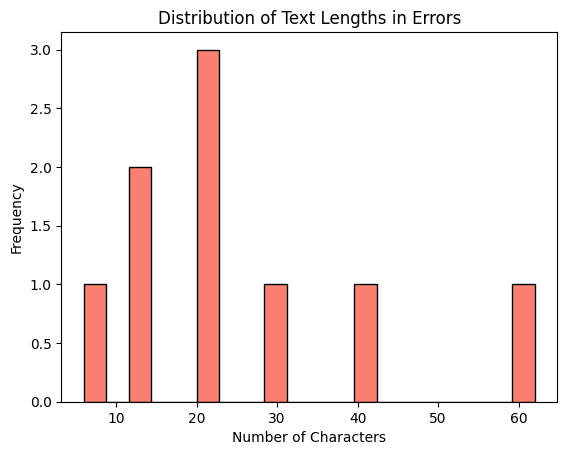

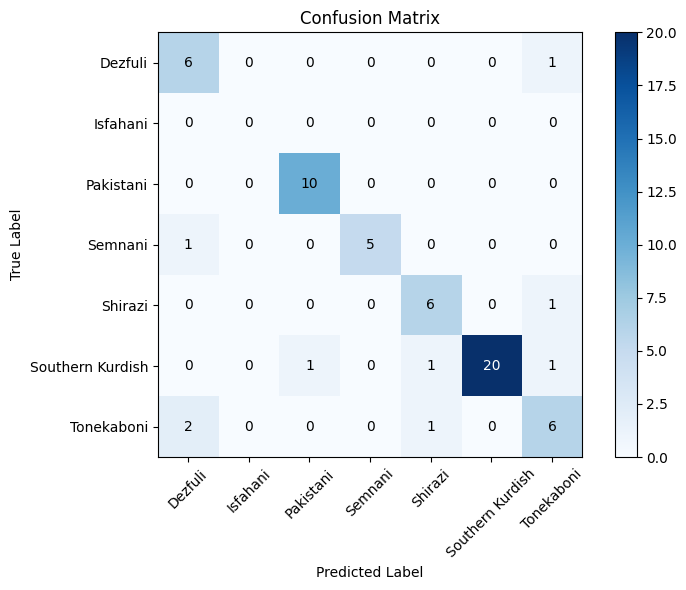

In [8]:
# this cell was added by myself to do ablation study
error_text_length = [len(error['text']) for error in errors]
plt.hist(error_text_length, bins=20, color='salmon', edgecolor='black')
plt.title('Distribution of Text Lengths in Errors')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.show()

# confusion matrix
confusion_matrix = np.zeros((len(accent2idx), len(accent2idx)), dtype=int)
for error in errors:
    true_idx = error['true_label']
    pred_idx = error['predicted_label']
    confusion_matrix[true_idx][pred_idx] += 1
for i in range(len(accent2idx)):
    confusion_matrix[i][i] = (
        test_df['accent'].map(accent2idx).value_counts().get(i, 0) 
        - confusion_matrix[i].sum() 
    )
plt.figure(figsize=(8, 6))
plt.imshow(confusion_matrix, interpolation='nearest', cmap=plt.cm.Blues)
for i in range(confusion_matrix.shape[0]):
    for j in range(confusion_matrix.shape[1]):
        plt.text(
            j, i, str(confusion_matrix[i, j]),
            ha="center", va="center",
            color="white" if confusion_matrix[i, j] > confusion_matrix.max() / 2 else "black"
        )
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(accent2idx))
plt.xticks(tick_marks, [idx2accent[i] for i in range(len(accent2idx))], rotation=45)
plt.yticks(tick_marks, [idx2accent[i] for i in range(len(accent2idx))])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right; line-height: 2; font-family: Vazir, Tahoma, sans-serif;">
<b>تحلیل خطاهای مدل:</b>
<br><br>
<i>(تحلیل خود را در قالب چند خط اینجا بنویسید. به کلمات خاص یا ساختار جملات استخراج‌شده در سلول قبل دقت کنید.)</i>
<br><br>
باتوجه به نمودارهای رسم شده در بخش قبل، مدل سوگیری خاصی نسبت به طول جمله و یا اشتباه گرفتن دوکلاس خاص با یکدیگر ندارد. 

به نظر می‌آید که مدل اندکی تمایل به گفتن لحجه شیرازی دارد، ولی مقدار آن زیاد نیست. با این تعداد داده نمی‌توان نتیجه گیری خاصی کرد.

اما اگر بخواهیم باتوجه به تعداد داده و معماری ساده مدل قضاوت کنیم، احتمالا مدل دچار کم‌برازش شده و مشکل سوگیری نیست  .
</div>